In [1]:
import matplotlib.pyplot as plt
import numpy as np
from tapas_gmm_modified.policy.models.tpgmm import (
    ReconstructionStrategy, 
    FittingStage,
    InitStrategy,

)
from tapas_gmm_modified.dataset.demos import Demos
from tapas_gmm_modified.viz.gmm import plot_hmm_transition_matrix

np.set_printoptions(precision=2)

plt.style.use('default')

from matplotlib import rc
rc('animation', html='jshtml')

2026-07-07 02:33:10.877 | INFO     |  Running on cpu


/home/jangruhnert/miniconda3/envs/hecarim/lib/python3.10/site-packages/riepybdlib/data.py:34: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_listdir


In [2]:
from heca.agents.experts.tapas import TapasAgent
from conf.agents.experts.tapas import close_window as agent_cfg
agent = TapasAgent.get(agent_cfg, auto_load=True)
print(agent_cfg.policy.model.frame_selection.gt_frames)
selections = [0, 4, 5,6,7]

2026-07-07 02:33:12.372 | INFO     | heca.misc.logger:info:30 - Running on cpu


/home/jangruhnert/miniconda3/envs/hecarim/lib/python3.10/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/jangruhnert/miniconda3/envs/hecarim/lib/python3.10/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


2026-07-07 02:33:13.969 | INFO     | heca.misc.logger:info:30 - Loading <class 'heca.agents.experts.tapas.TapasAgent'> from /home/jangruhnert/Documents/GitHub/master-project/data/agents/tapas/close_window
2026-07-07 02:33:13.969 | INFO     | tapas_gmm_modified.utils.logging:wrapper:67 - Initializing Policy:
2026-07-07 02:33:13.970 | INFO     | tapas_gmm_modified.encoder:get_image_encoder_class:62 - No encoder config provided. Using None.
2026-07-07 02:33:13.970 | WARNING  | heca.misc.logger:warning:26 - No tapas policy found at given path: /home/jangruhnert/Documents/GitHub/master-project/data/agents/tapas/close_window/policy_gt.pt
GMMPolicy(
  (obs_encoder): ObservationEncoder()
)
[[0, 5], [5, 3], [5, 7]]


In [3]:
observations = agent.load_demos(selections)

demos = Demos(
    observations,
    add_init_ee_pose_as_frame=True,
    add_world_frame=False,
    frames_from_keypoints=False,
    kp_indeces=None,
    enforce_z_up=False,
    modulo_object_z_rotation=False,
    make_quats_continuous=True,
)  # type: ignore
print("n_trajs", demos.n_trajs)
print("n_frames", demos.n_frames)
print(demos.frame_names)
print(demos.idx_key_list)

2026-07-07 02:33:28.407 | INFO     | tapas_gmm_modified.dataset.demos:subsample_to_common_length:609 - Subsampling to length 44 using strategy mean-length.
n_trajs 5
n_frames 8
('ee_init', 'block_0', 'button_0', 'button_1', 'drawer_handle', 'window_handle', 'block_0_target', 'ee_target')
['ee', 'block_0', 'button_0', 'button_1', 'drawer_handle', 'window_handle', 'block_0_target', 'ee_target']


2026-07-07 02:33:28.418 | INFO     | tapas_gmm_modified.policy.models.tpgmm:fit_trajectories:2740 - Fitting AutoTPGMM
2026-07-07 02:33:28.418 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [INIT]
2026-07-07 02:33:28.418 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_segment_and_frame_select:2860 - Segmenting trajectories


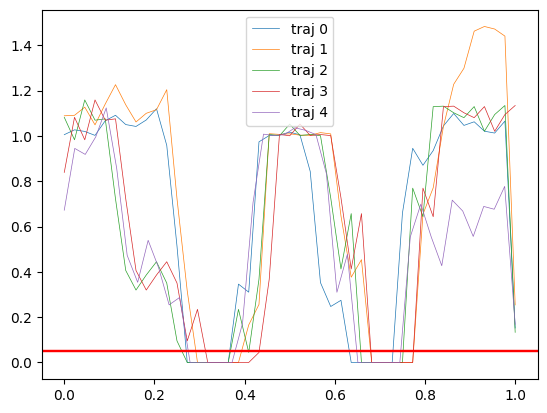

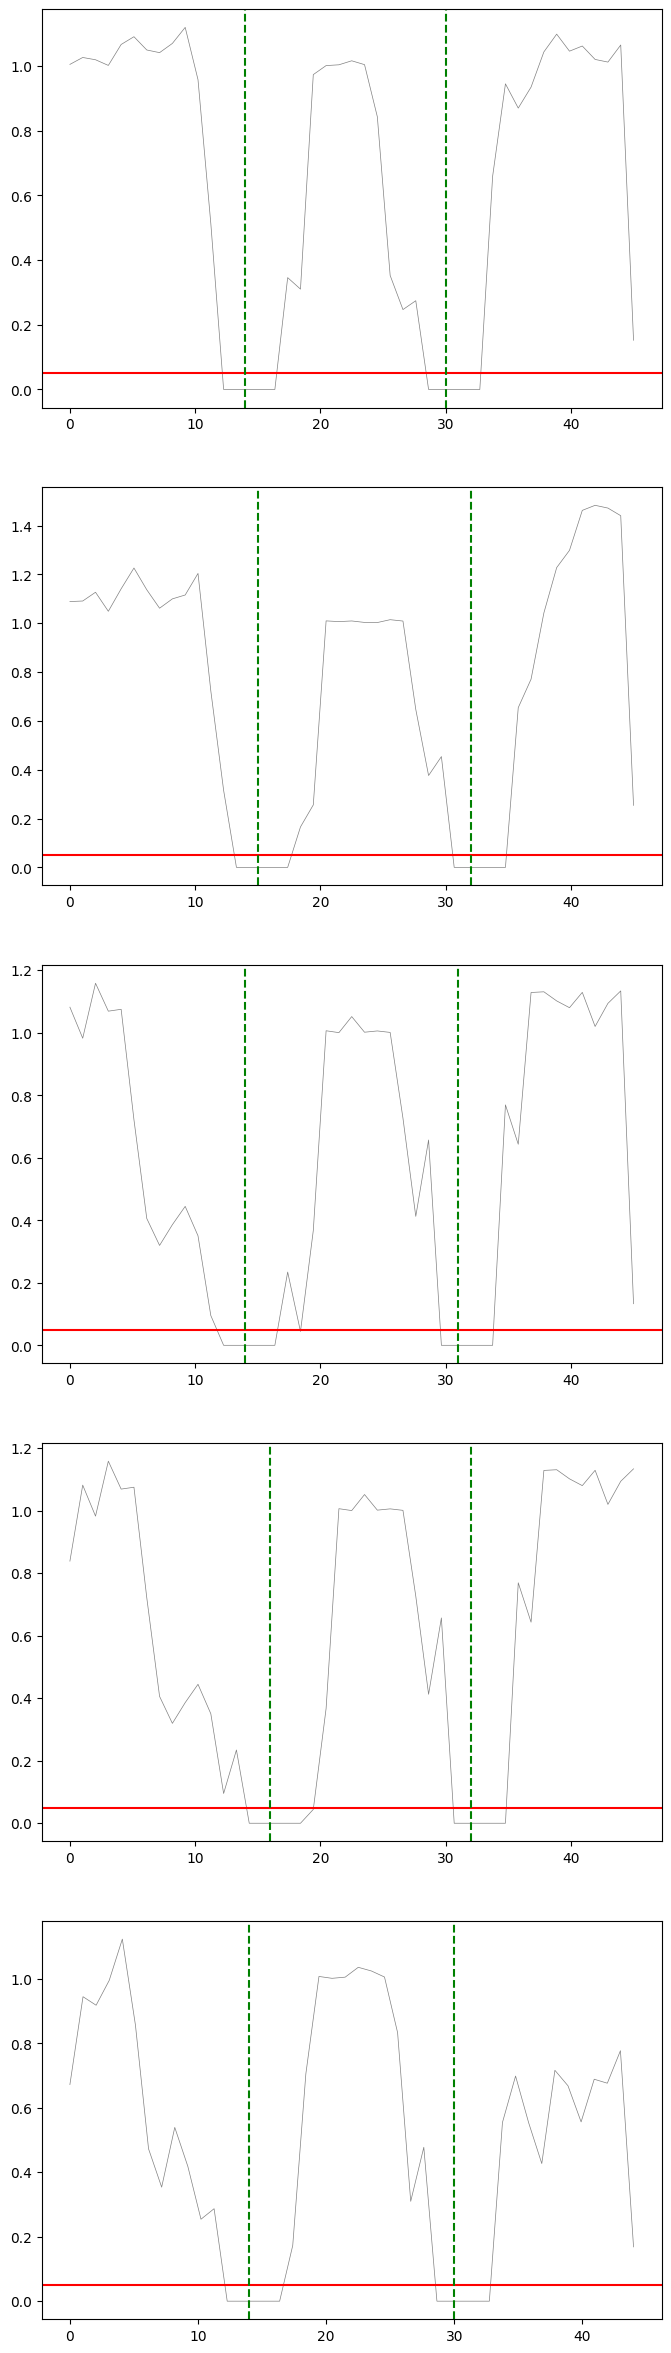

2026-07-07 02:33:28.690 | INFO     | tapas_gmm_modified.dataset.demos:__init__:2697 - Creating segement of demos.
2026-07-07 02:33:28.691 | INFO     | tapas_gmm_modified.dataset.demos:subsample_to_common_length:609 - Subsampling to length 14 using strategy mean-length.
2026-07-07 02:33:28.691 | INFO     | tapas_gmm_modified.dataset.demos:__init__:2697 - Creating segement of demos.
2026-07-07 02:33:28.692 | INFO     | tapas_gmm_modified.dataset.demos:subsample_to_common_length:609 - Subsampling to length 16 using strategy mean-length.
2026-07-07 02:33:28.692 | INFO     | tapas_gmm_modified.dataset.demos:__init__:2697 - Creating segement of demos.
2026-07-07 02:33:28.693 | INFO     | tapas_gmm_modified.dataset.demos:subsample_to_common_length:609 - Subsampling to length 13 using strategy mean-length.
2026-07-07 02:33:28.693 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_segment_and_frame_select:2865 - ... created 3 segments
2026-07-07 02:33:28.693 | INFO     | tapas_gmm_modified.po

Time-based init:   0%|          | 0/6 [00:00<?, ?it/s]

2026-07-07 02:33:28.722 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_frames:3043 - Fitting candidate frame 2/8
2026-07-07 02:33:28.722 | INFO     | tapas_gmm_modified.dataset.demos:__init__:2470 - Creating partial frame view of demos.
2026-07-07 02:33:28.722 | INFO     | tapas_gmm_modified.dataset.demos:subsample_to_common_length:609 - Subsampling to length 14 using strategy mean-length.
2026-07-07 02:33:28.725 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_setup_manifold:735 - Manifold: TIME x R3 x QUAT x R1
2026-07-07 02:33:28.725 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 6
2026-07-07 02:33:28.725 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [INIT]
2026-07-07 02:33:28.725 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_rbd_init:1195 - Model init ...


Time-based init:   0%|          | 0/6 [00:00<?, ?it/s]

2026-07-07 02:33:28.766 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_frames:3043 - Fitting candidate frame 3/8
2026-07-07 02:33:28.767 | INFO     | tapas_gmm_modified.dataset.demos:__init__:2470 - Creating partial frame view of demos.
2026-07-07 02:33:28.767 | INFO     | tapas_gmm_modified.dataset.demos:subsample_to_common_length:609 - Subsampling to length 14 using strategy mean-length.
2026-07-07 02:33:28.770 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_setup_manifold:735 - Manifold: TIME x R3 x QUAT x R1
2026-07-07 02:33:28.770 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 6
2026-07-07 02:33:28.770 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [INIT]
2026-07-07 02:33:28.770 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_rbd_init:1195 - Model init ...


...

2026-07-07 02:33:30.070 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_setup_manifold:735 - Manifold: TIME x R3 x QUAT x R3 x QUAT x R1
2026-07-07 02:33:30.071 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 7
2026-07-07 02:33:30.071 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [INIT]
2026-07-07 02:33:30.071 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_rbd_init:1195 - Model init ...


Time-based init:   0%|          | 0/7 [00:00<?, ?it/s]

2026-07-07 02:33:30.146 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_setup_manifold:735 - Manifold: TIME x R3 x QUAT x R3 x QUAT x R1
2026-07-07 02:33:30.146 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 6
2026-07-07 02:33:30.146 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [INIT]
2026-07-07 02:33:30.146 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_rbd_init:1195 - Model init ...


Time-based init:   0%|          | 0/6 [00:00<?, ?it/s]

((array([[8.52e+013, 3.23e+014, 1.57e+014, 1.26e+013, 2.38e+011, 5.48e+008,
          1.28e+005, 4.37e+000, 8.23e-006, 2.56e-011, 1.97e-019, 4.61e-045,
          1.44e-118, 1.31e-121, 8.56e+013, 2.27e+014, 1.48e+014, 1.37e+013,
          2.79e+010, 6.29e+007, 8.17e+005, 8.02e+000, 3.29e-003, 7.06e-008,
          8.21e-019, 3.97e-049, 2.57e-117, 2.05e-121, 2.65e+014, 5.16e+014,
          1.92e+014, 9.93e+012, 1.01e+011, 5.28e+008, 8.66e+006, 1.85e+004,
          1.24e+001, 3.95e-003, 1.52e-009, 9.08e-031, 2.11e-076, 6.08e-080,
          2.08e+014, 4.32e+014, 2.75e+014, 2.87e+013, 7.31e+008, 1.31e+006,
          1.02e+004, 1.00e+001, 3.55e-003, 6.80e-007, 1.73e-033, 6.86e-079,
          2.98e-167, 6.51e-171, 8.07e+013, 2.09e+014, 1.13e+014, 2.74e+013,
          2.44e+011, 4.54e+009, 5.69e+008, 5.15e+007, 1.51e+006, 7.25e+003,
          4.49e-003, 5.55e-024, 1.95e-070, 3.67e-075],
         [4.71e+006, 1.29e+010, 1.40e+013, 2.92e+014, 2.52e+014, 9.41e+012,
          1.18e+010, 5.37e+005, 1

In [4]:
agent.model.fit_trajectories(demos, fix_frames=True,
                       init_strategy=InitStrategy.TIME_BASED,
                       fitting_actions=(FittingStage.INIT,))


2026-07-07 02:33:30.312 | INFO     | tapas_gmm_modified.policy.models.tpgmm:plot_model:3856 - Did not specify time_based, deciding automatically.
2026-07-07 02:33:30.348 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:33:30.348 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:33:30.348 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:33:30.348 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:33:30.348 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:33:30.348 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:33:30.348 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:33:30.348 | WARNING  | tapas_gmm_modified.viz.gmm

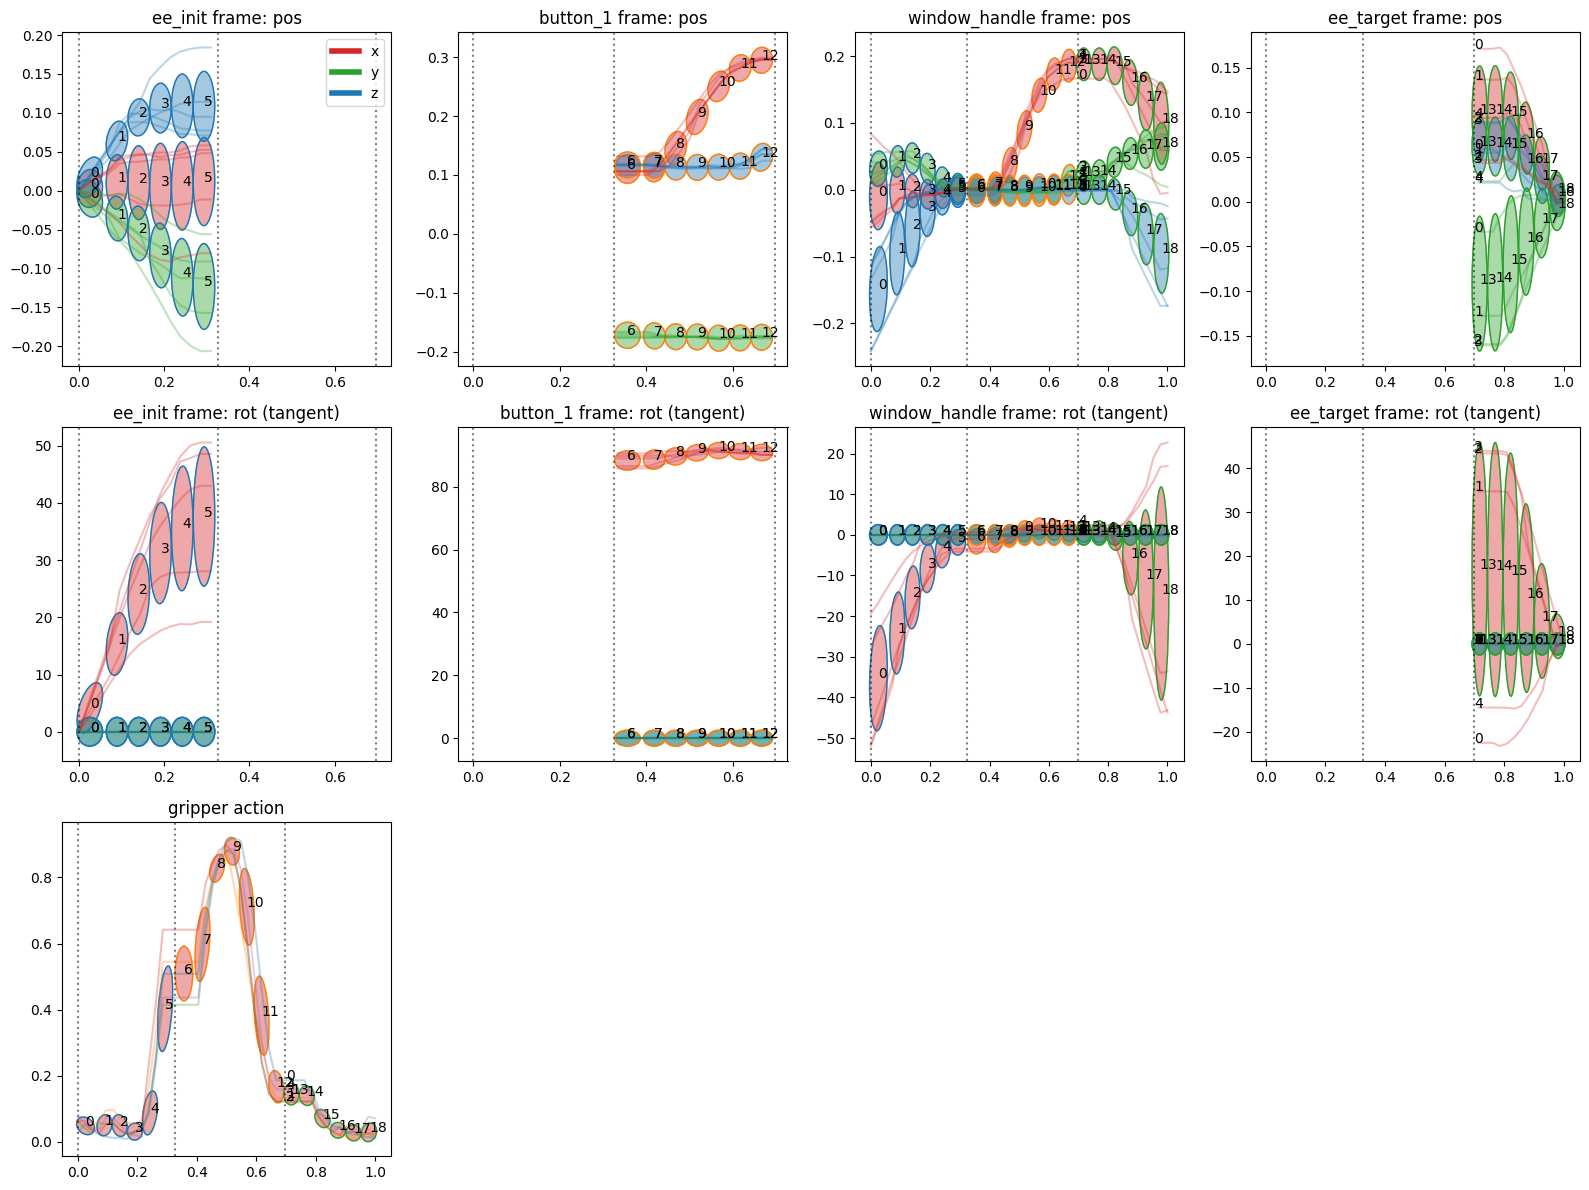

In [5]:
agent.model.plot_model(scatter=True, annotate_gaussians=True, annotate_trajs=True, mean_as_base=False)


In [6]:
agent.model.fit_trajectories(demos, fix_frames=True, fitting_actions=(FittingStage.EM_HMM, ))


2026-07-07 02:33:31.987 | INFO     | tapas_gmm_modified.policy.models.tpgmm:fit_trajectories:2740 - Fitting AutoTPGMM
2026-07-07 02:33:31.987 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [EM_HMM]


Fitting segments:   0%|          | 0/3 [00:00<?, ?it/s]

2026-07-07 02:33:31.990 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [EM_HMM]
2026-07-07 02:33:31.990 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_rbd_hmm:1296 - HMM EM ...
2026-07-07 02:33:31.992 | INFO     | riepybdlib.statistics:trans:1710 - HMM transition matrix not defined, initializing to uniform


HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

2026-07-07 02:33:32.003 | INFO     | riepybdlib.statistics:init_priors:1698 - HMM init priors not defined, initializing to uniform
2026-07-07 02:33:36.070 | INFO     | riepybdlib.statistics:em:2249 - HMM EM converged
2026-07-07 02:33:36.086 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [EM_HMM]
2026-07-07 02:33:36.086 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_rbd_hmm:1296 - HMM EM ...
2026-07-07 02:33:36.088 | INFO     | riepybdlib.statistics:trans:1710 - HMM transition matrix not defined, initializing to uniform


HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

2026-07-07 02:33:36.099 | INFO     | riepybdlib.statistics:init_priors:1698 - HMM init priors not defined, initializing to uniform
2026-07-07 02:33:37.084 | INFO     | riepybdlib.statistics:em:2249 - HMM EM converged
2026-07-07 02:33:37.106 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [EM_HMM]
2026-07-07 02:33:37.106 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_rbd_hmm:1296 - HMM EM ...
2026-07-07 02:33:37.108 | INFO     | riepybdlib.statistics:trans:1710 - HMM transition matrix not defined, initializing to uniform


HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

2026-07-07 02:33:37.118 | INFO     | riepybdlib.statistics:init_priors:1698 - HMM init priors not defined, initializing to uniform
2026-07-07 02:33:41.392 | INFO     | riepybdlib.statistics:em:2249 - HMM EM converged


((array([[1.00e+000, 9.51e-001, 3.17e-002, 5.70e-007, 6.08e-017, 2.20e-035,
          4.11e-067, 9.45e-114, 3.23e-174, 4.67e-245, 0.00e+000, 0.00e+000,
          0.00e+000, 0.00e+000, 1.00e+000, 1.00e+000, 6.82e-001, 7.28e-003,
          2.22e-009, 2.05e-026, 1.10e-055, 2.71e-097, 3.33e-148, 6.46e-205,
          1.03e-257, 1.52e-298, 0.00e+000, 0.00e+000, 1.00e+000, 8.00e-001,
          1.63e-002, 1.47e-007, 9.25e-018, 4.04e-034, 3.46e-058, 1.06e-091,
          4.26e-135, 5.57e-187, 6.11e-241, 6.26e-293, 0.00e+000, 0.00e+000,
          1.00e+000, 9.13e-001, 3.63e-002, 6.72e-009, 5.61e-025, 2.51e-048,
          2.69e-081, 5.79e-125, 5.92e-180, 1.30e-244, 0.00e+000, 0.00e+000,
          0.00e+000, 0.00e+000, 1.00e+000, 9.99e-001, 8.31e-001, 5.13e-003,
          9.31e-010, 5.28e-021, 4.31e-037, 3.32e-059, 2.90e-089, 1.67e-127,
          3.12e-167, 1.16e-198, 2.83e-217, 3.07e-225],
         [3.02e-155, 4.86e-002, 9.68e-001, 1.00e+000, 9.72e-001, 2.24e-002,
          3.21e-008, 2.40e-022, 7

2026-07-07 02:33:41.452 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:33:41.452 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:33:41.452 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:33:41.452 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:33:41.452 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:33:41.452 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:33:41.452 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:33:41.452 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:33:41.452 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippi

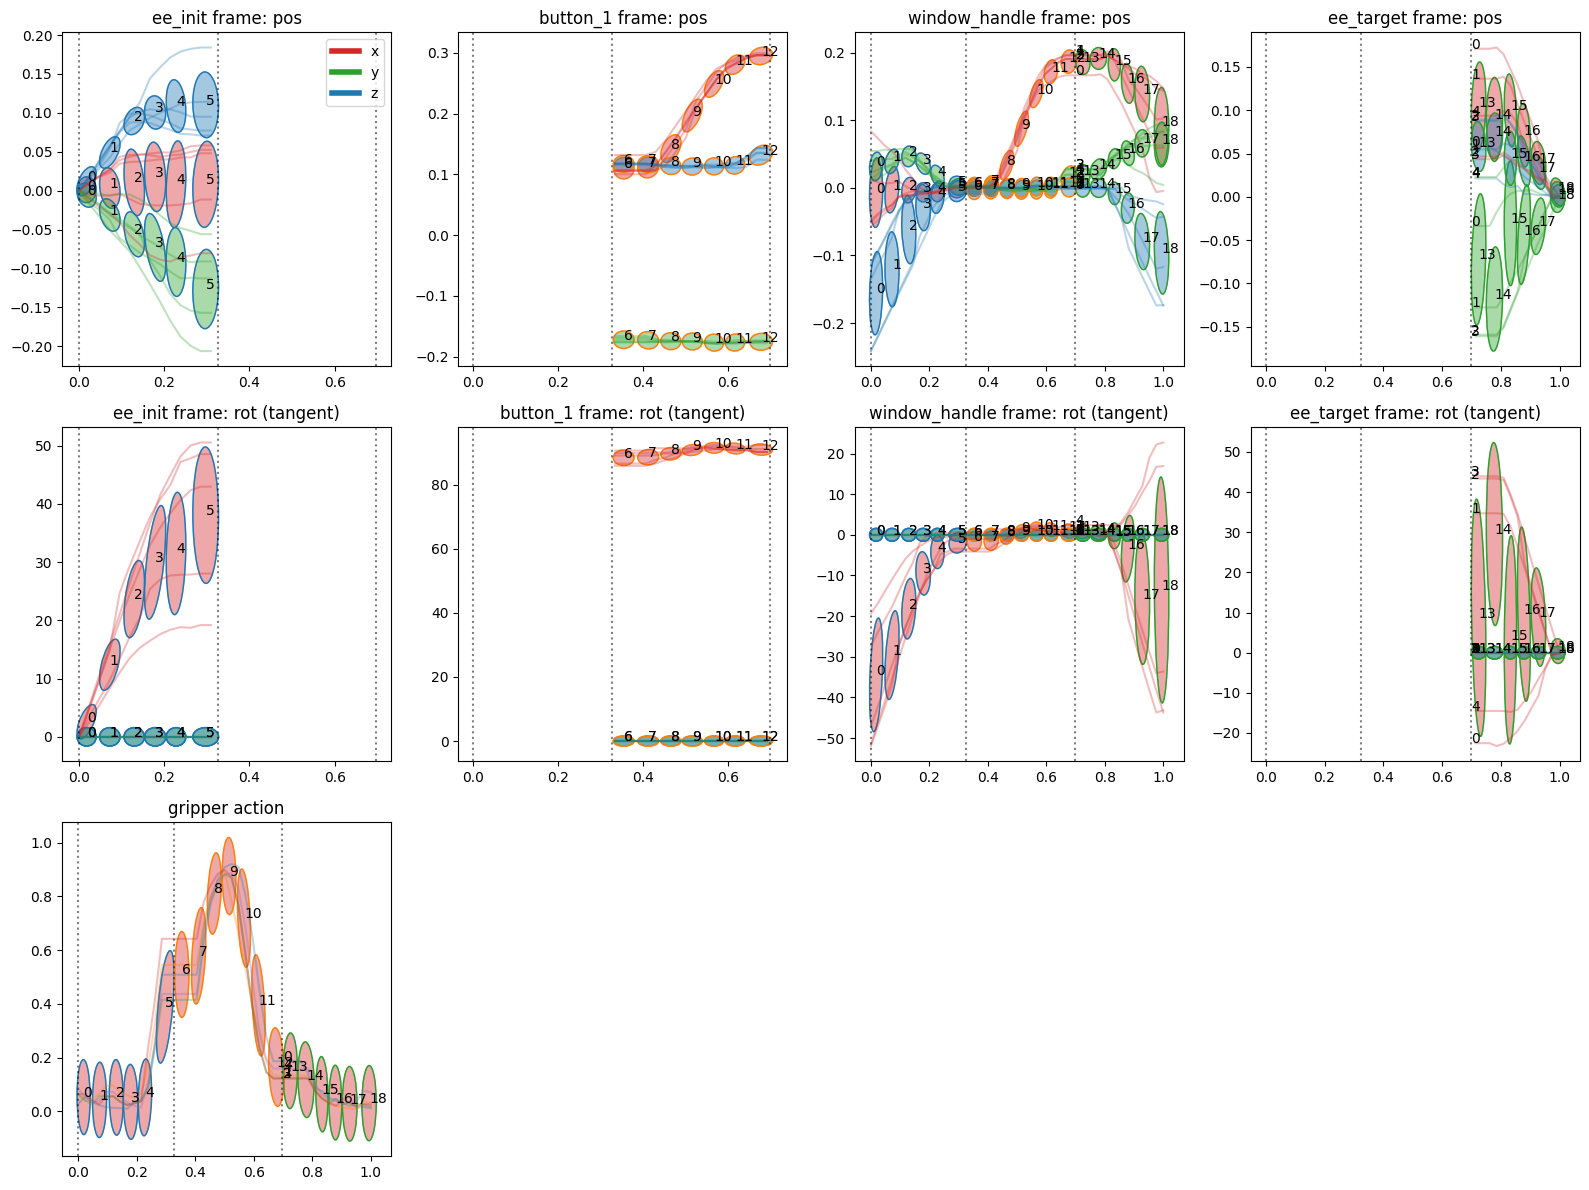

In [7]:
agent.model.plot_model(
    scatter=True, annotate_gaussians=True, annotate_trajs=True, mean_as_base=False, time_based=True,
)

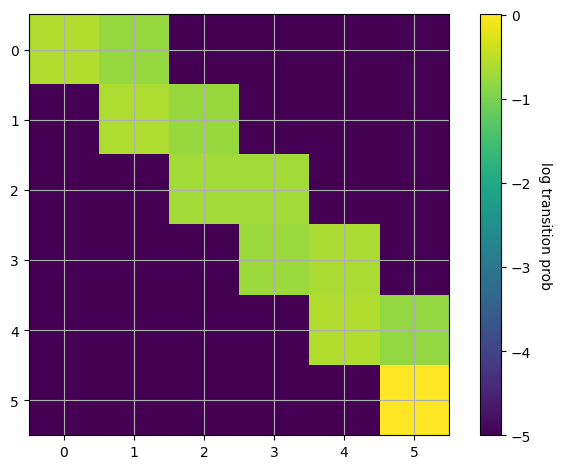

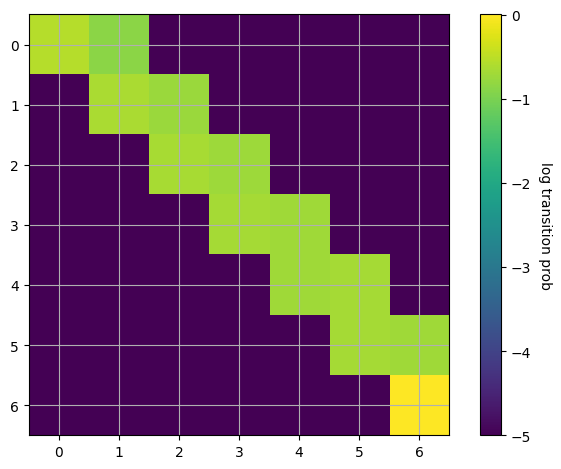

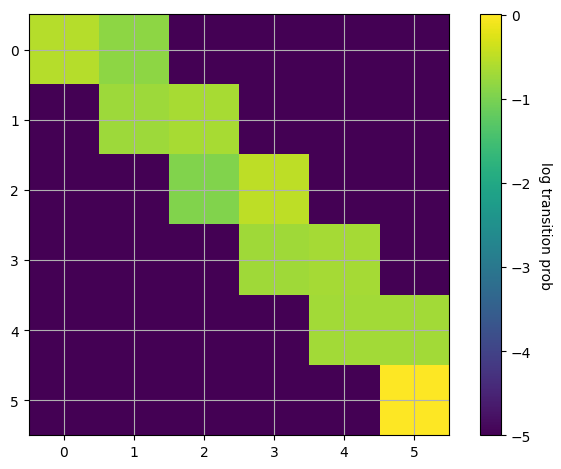

In [8]:
agent.model.plot_hmm_transition_matrix()

In [9]:
agent.save()

2026-07-07 02:33:43.087 | INFO     | heca.misc.logger:info:30 - Saving <class 'heca.agents.experts.tapas.TapasAgent'> to /home/jangruhnert/Documents/GitHub/master-project/data/agents/tapas/close_window
2026-07-07 02:33:43.088 | INFO     | heca.misc.logger:info:30 - Saving tapas policy to: /home/jangruhnert/Documents/GitHub/master-project/data/agents/tapas/close_window/policy_gt.pt
2026-07-07 02:33:43.088 | INFO     | tapas_gmm_modified.policy.models.tpgmm:to_disk:2617 - Saving model:


In [10]:
seg_local_marginals, seg_trans_marginals, seg_trans_marg_container, seg_joint_models, cascaded_hmms, (reconstructions, original_trajectories, extras) = agent.model.reconstruct(
    strategy=ReconstructionStrategy.GMR,
    use_ss=False)


2026-07-07 02:33:43.137 | INFO     | tapas_gmm_modified.policy.models.tpgmm:reconstruct:3239 - Time-based reconstruction not specified. Auto selected True.
2026-07-07 02:33:53.598 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_cascade_segment_hmms:3343 - Caculated segment transition probabilities: (array([[0.07]]), array([[0.15]]))
2026-07-07 02:33:53.598 | INFO     | tapas_gmm_modified.dataset.demos:__init__:2470 - Creating partial frame view of demos.
2026-07-07 02:33:53.598 | INFO     | tapas_gmm_modified.dataset.demos:subsample_to_common_length:609 - Subsampling to length 44 using strategy mean-length.
2026-07-07 02:33:53.600 | INFO     | tapas_gmm_modified.dataset.demos:_frame_quats2world_velocities:807 - Assuming zero frame velocity. Should be fixed.
2026-07-07 02:33:53.600 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 6
2026-07-07 02:33:53.600 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of component

Transforming marginals:   0%|          | 0/5 [00:00<?, ?it/s]

2026-07-07 02:33:53.605 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 6
2026-07-07 02:33:53.607 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 6
2026-07-07 02:33:53.610 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 6
2026-07-07 02:33:53.612 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 6
2026-07-07 02:33:53.614 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 6
2026-07-07 02:33:53.616 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 6
2026-07-07 02:33:53.618 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 6
2026-07-07 02:33:53.620 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 6
2026-07-07 02:33:53.622 | INFO     | riepybdlib.statistics:set_n

Joining marginals:   0%|          | 0/5 [00:00<?, ?it/s]

2026-07-07 02:33:53.630 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 6
2026-07-07 02:33:53.647 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 6
2026-07-07 02:33:53.654 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 6
2026-07-07 02:33:53.660 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 6
2026-07-07 02:33:53.666 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 6
2026-07-07 02:33:53.671 | INFO     | tapas_gmm_modified.dataset.demos:__init__:2470 - Creating partial frame view of demos.
2026-07-07 02:33:53.671 | INFO     | tapas_gmm_modified.dataset.demos:subsample_to_common_length:609 - Subsampling to length 44 using strategy mean-length.
2026-07-07 02:33:53.672 | INFO     | tapas_gmm_modified.dataset.demos:_frame_quats2world_velocities:807 - Assuming zero frame velocity.

...

2026-07-07 02:33:53.734 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 6
2026-07-07 02:33:53.737 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 6
2026-07-07 02:33:53.739 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 6
2026-07-07 02:33:53.741 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 6
2026-07-07 02:33:53.742 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 6
2026-07-07 02:33:53.744 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 6
2026-07-07 02:33:53.745 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 6
2026-07-07 02:33:53.746 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 6
2026-07-07 02:33:53.748 | INFO     | riepybdlib.statistics:set_n

Joining marginals:   0%|          | 0/5 [00:00<?, ?it/s]

2026-07-07 02:33:53.754 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 6
2026-07-07 02:33:53.761 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 6
2026-07-07 02:33:53.768 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 6
2026-07-07 02:33:53.775 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 6
2026-07-07 02:33:53.781 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 6
2026-07-07 02:33:53.788 | WARNING  | riepybdlib.statistics:__init__:2454 - Setting init priors of later segments to zero.
2026-07-07 02:33:53.789 | WARNING  | riepybdlib.statistics:__init__:2454 - Setting init priors of later segments to zero.
2026-07-07 02:33:53.789 | WARNING  | riepybdlib.statistics:__init__:2454 - Setting init priors of later segments to zero.
2026-07-07 02:33:53.789 | WARNING  | riepybdlib.s

GMR:   0%|          | 0/5 [00:00<?, ?it/s]

2026-07-07 02:33:53.793 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 6
2026-07-07 02:33:53.793 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 7
2026-07-07 02:33:53.794 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 6
2026-07-07 02:33:54.004 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 6
2026-07-07 02:33:54.004 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 7
2026-07-07 02:33:54.004 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 6
2026-07-07 02:33:54.191 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 6
2026-07-07 02:33:54.192 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 7
2026-07-07 02:33:54.192 | INFO     | riepybdlib.statistics:set_n

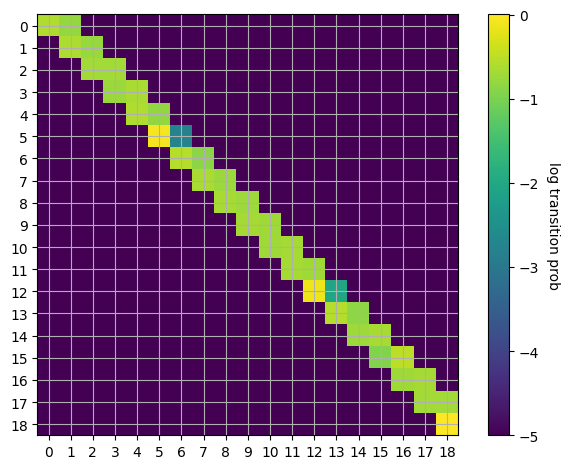

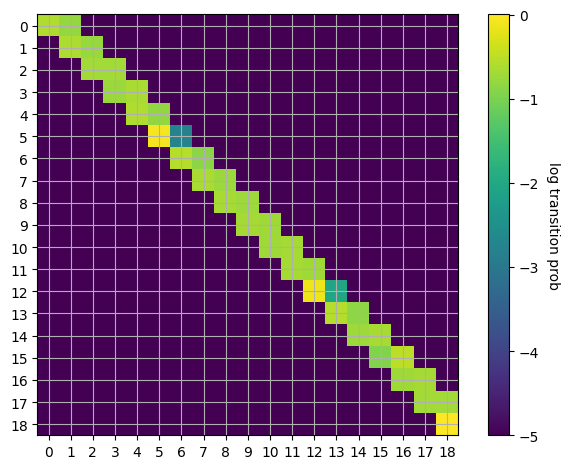

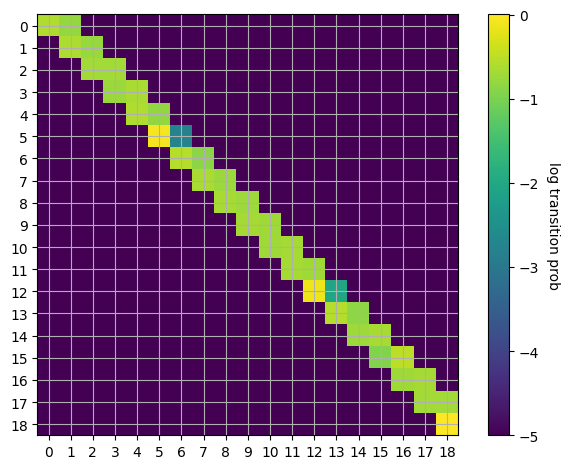

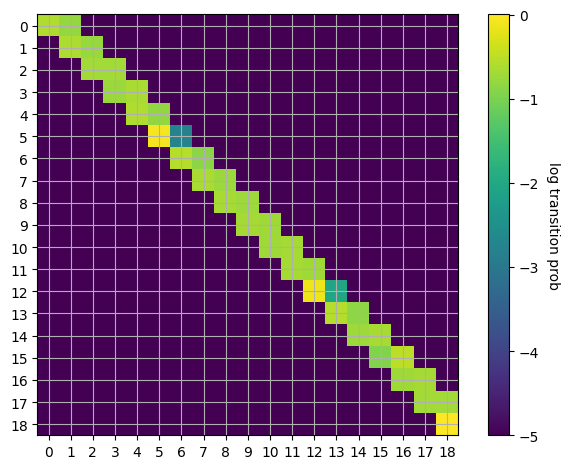

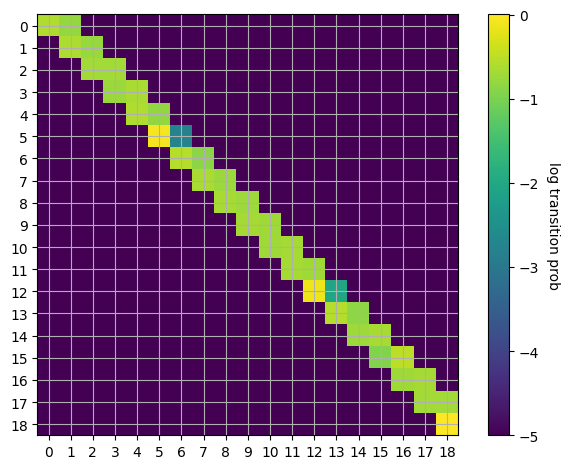

In [11]:
for cascaded_hmm in cascaded_hmms:
    plot_hmm_transition_matrix(cascaded_hmm)

2026-07-07 02:33:55.443 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_plot_reconstructions_jointly:4105 - Taking frame origins from demos.


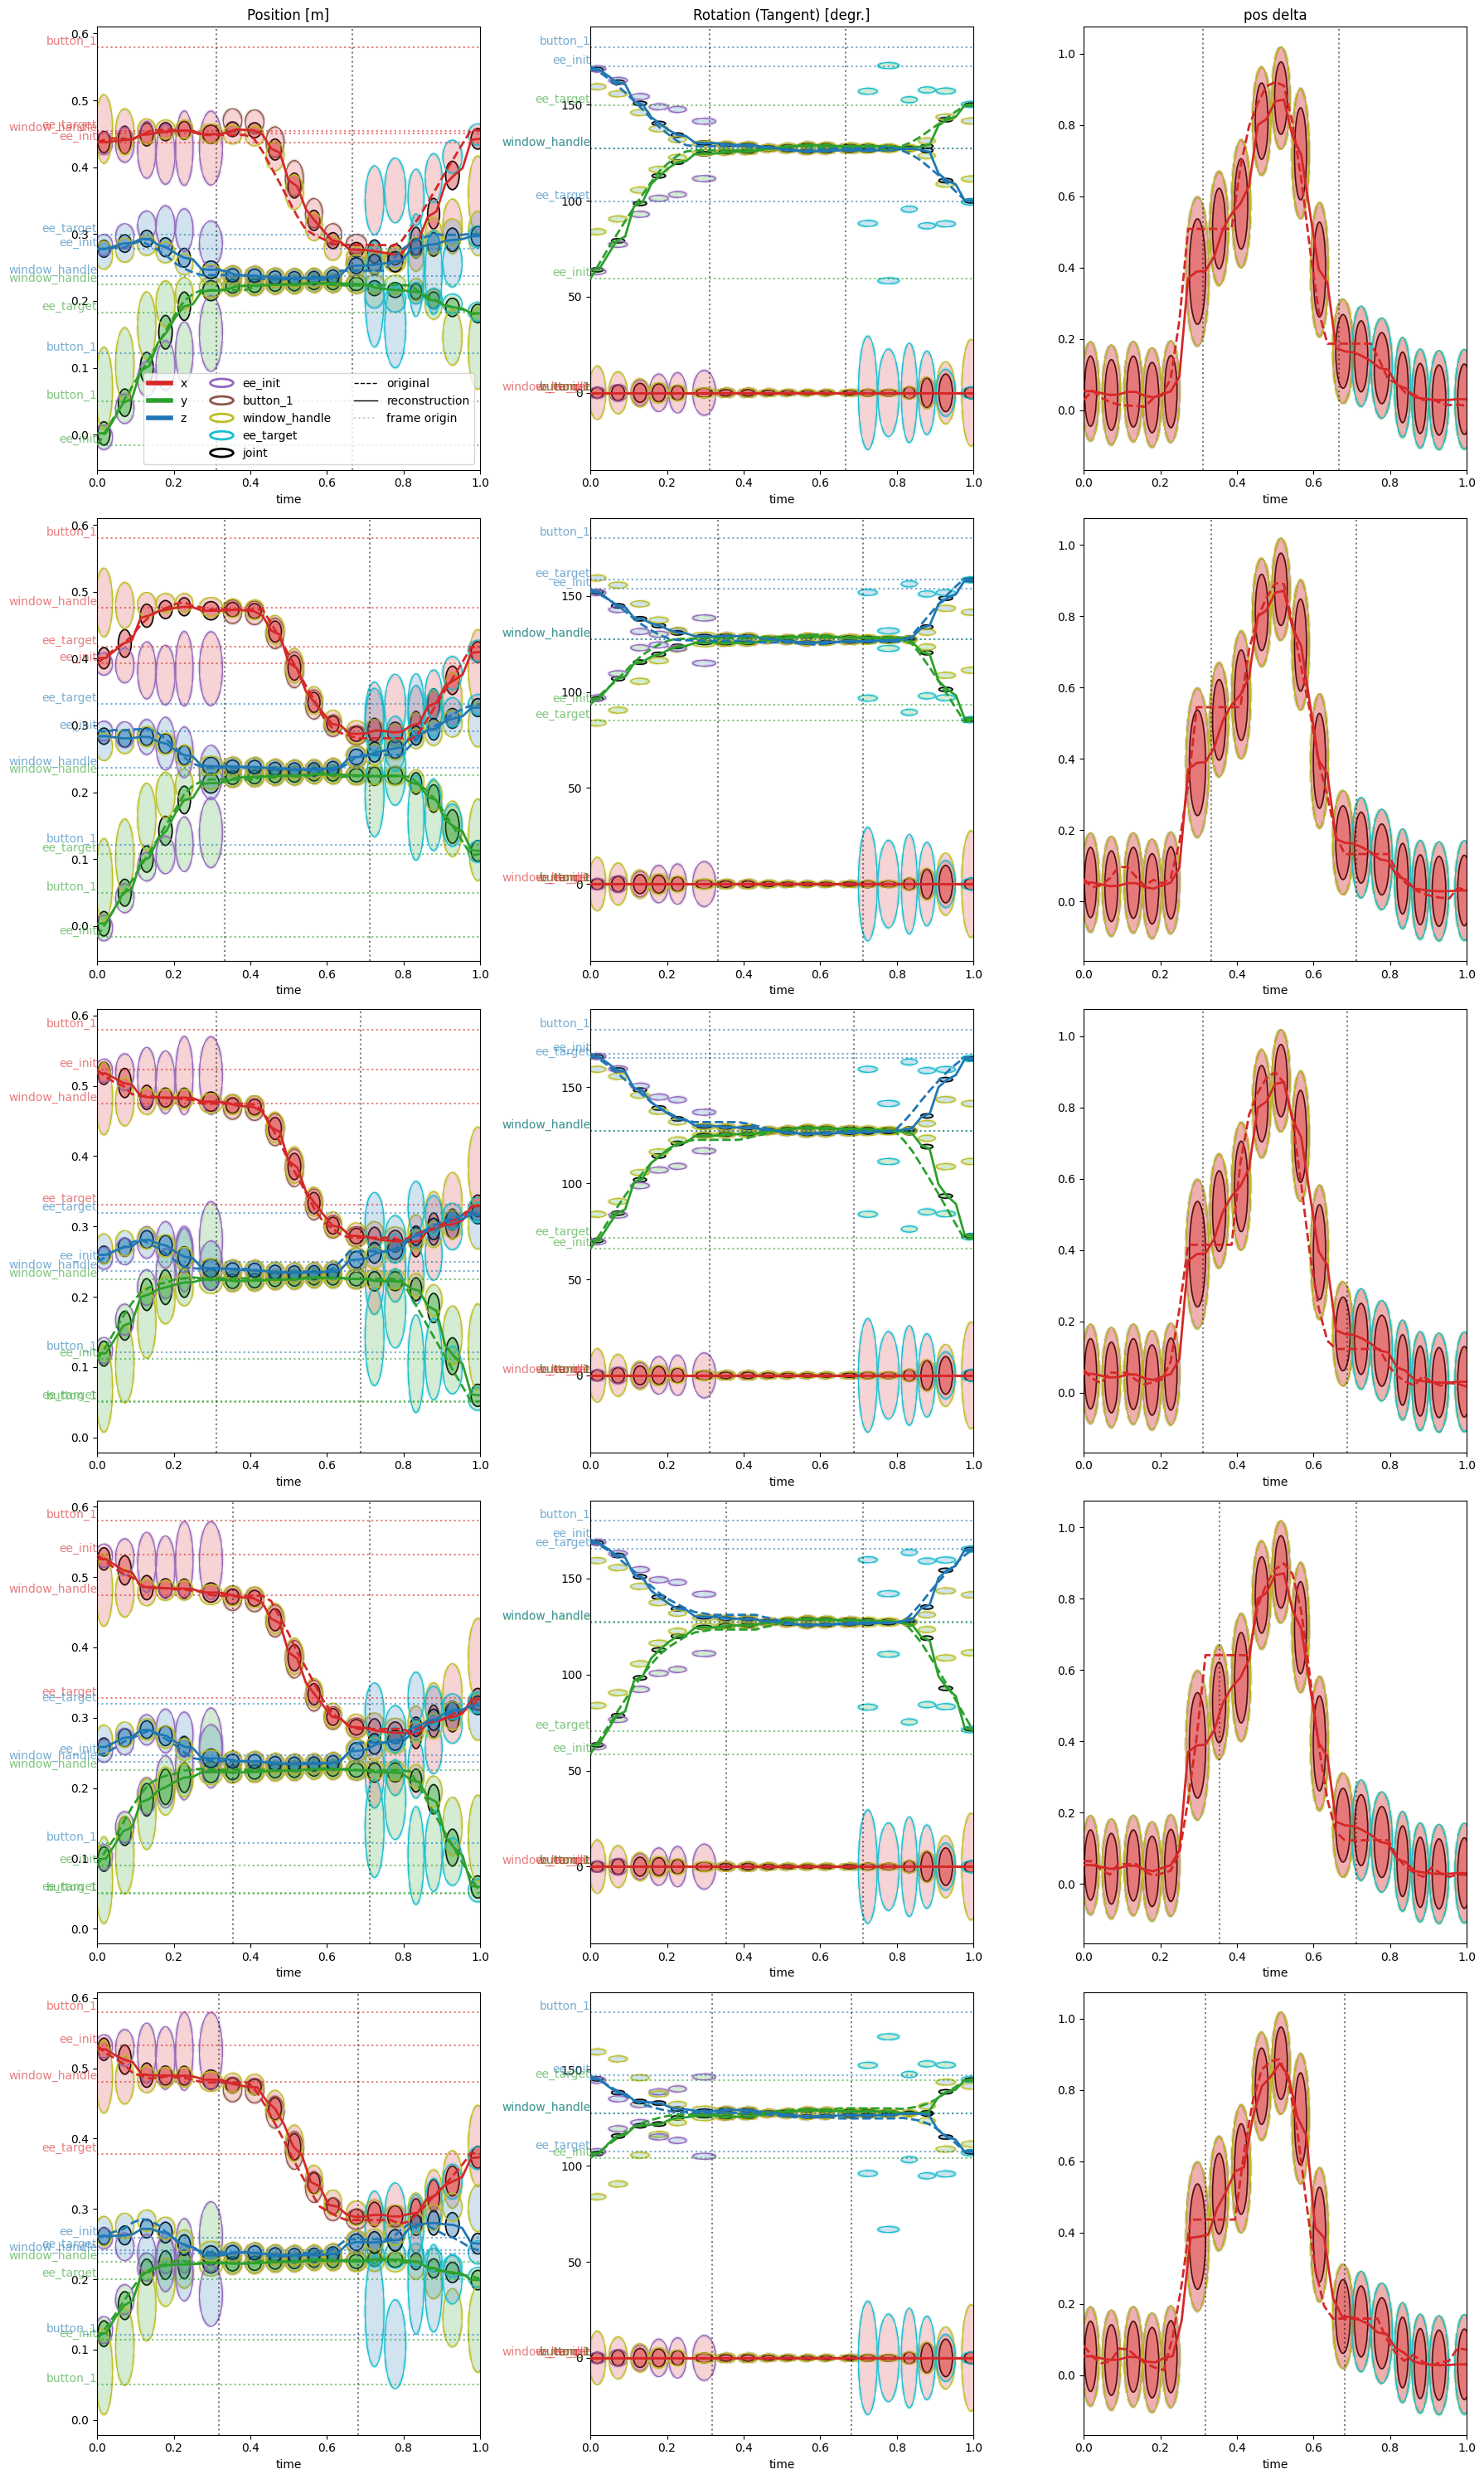

In [12]:
agent.model.plot_reconstructions(
    seg_trans_marg_container,
    cascaded_hmms,
    reconstructions,
    original_trajectories,
    plot_trajectories=True,
    plot_reconstructions=True,
    plot_gaussians=True,
    time_based=True,
    equal_aspect=False,
    per_segment=False,
)

In [13]:
agent.model.plot_reconstructions(
    seg_trans_marginals,
    seg_joint_models,
    reconstructions,
    original_trajectories,
    plot_trajectories=True,
    plot_reconstructions=True,
    plot_gaussians=True,
    time_based=False,
    equal_aspect=True,
    per_segment=False,
)

IndexError: tuple index out of range